# Building a Custom LLM with nanoGPT
**Class 4 | From Zero to AI Agents | Fall 26**

Train from scratch using **Karpathy's actual nanoGPT transformer** in PyTorch.
Our classroom tokenizer uses **whole words and punctuation**. nanoGPT does not
dictate tokenization: its examples include characters and GPT-2 subwords. Word
tokens are our teaching choice, not a new architecture or pretrained embeddings.
Your job is to choose, predict, run, inspect, and explain, not implement the network.
A small model on a narrow corpus is not a chat assistant or a general map of meaning.

[Assignment](https://docs.google.com/document/d/1MQ3YQl2ywWZF7W5_l_91FiIp7pTYPO_3viI2JVapRcc/edit)
| [Sample project](https://github.com/pepealonso95/custom-llm)
| [nanoGPT source](https://github.com/karpathy/nanoGPT)

## How Evals Affect Your Assignment Grade

This assignment is graded out of 10 using the course framework: deliverable quality (4 points), testing & evaluation (3 points), and working result (3 points). The 48-case eval percentage is a model measurement, not your assignment grade. The runner does not calculate your grade.

- Deliverable quality (4 points): submit both executed experiments, readable source code, corpus sources and choices, and a clear README. Explain the model's learning process using your actual token, embedding, gradient, and loss evidence. Explain why you chose at least two extension categories and how your new teaching material addresses their gaps.

- Testing & evaluation (3 points): run all 48 unchanged cases before and after training in each experiment. That means four complete result sets: starter untrained, starter trained, expanded-corpus untrained, and expanded-corpus trained. Save every case, the CSV/JSON results, summaries, and separation checks. Compare all-case success, scorable accuracy, vocabulary coverage, group/category scores, and actual free continuations, alongside the existing loss evidence. Explain failures and whether changes reflect vocabulary coverage, learned patterns, or both.

- Working result (3 points): demonstrate your trained nanoGPT, rerunnable evals on your saved model, and a working interface that produces actual replies from that model. Include launch instructions, the model/run identity, and at least 3 real chat interactions with a screenshot or recording. A terminal or notebook interface is sufficient; a polished website is not required.

Running and interpreting the evals is required. Missing runs, omitted cases, a missing corpus-extension comparison, or unsupported conclusions reduce testing & evaluation credit. Results produced by training on test prompts or answer keys are not valid evaluation evidence; remove the leakage and rerun. Incomplete notebook/code or a nonworking model/interface also affects the relevant deliverable or working-result category. Partial credit follows the evidence provided; this is not an automatic all-or-nothing checklist.

There is no minimum model pass rate, leaderboard, or required numerical improvement. A low score, unknown-word cases, or an extension experiment that does not improve can still earn full testing & evaluation credit when the required experiments are complete, the method is valid, and the analysis explains what happened. Unknown-word cases count as zero in the model's all-case metric, not as an automatic deduction of the same percentage from your grade. A high score alone cannot replace valid evaluation, understanding, and a working deliverable.

Before submitting, make the README show a four-row comparison for the two experiments and their untrained/trained stages, link all four result sets, identify the extension categories and added data, discuss at least one concrete failure or limitation, and link your chat evidence.

## 1. Make three choices
**Corpus:** put PDF, TXT or Markdown files in `corpus/` to expand the supplied
classroom sentences. Set CORPUS="folder" to use only your files instead.
**Training steps:** 10 checks setup; start with 3,000 for the experiment. One step
updates weights using 32 documents, not the entire corpus. Try 5,000 or 10,000 later
if useful, but compare validation loss rather than assuming more is better.
**Learning rate:** start at 0.001, with warmup and cosine decay in the training cell.
Write your reasons and prediction before running. AI assistants helping a student
should ask for these choices before training and explain actual outputs.

In [1]:
CORPUS = "classroom"       # Teaching sentences + files; "folder" uses only files
CORPUS_FOLDER = "corpus"   # Add .pdf, .txt and .md files here, including subfolders
TRAINING_STEPS = 3000      # 10 for setup; 3000 for the main experiment
LEARNING_RATE = 0.0003

### My prediction
I keep the defaults: 3,000 steps and a learning rate of 0.001. The reference run in
the template reached a panel loss of 0.69 by step 1,500 and 0.70 at 3,000, so 3,000
is already past the knee of the curve, and 0.001 did not diverge in that run.
The loss starts at 4.93. That is ln(136), the loss of a uniform guess over the 136-word
vocabulary. I expect the validation panel loss to end between 0.5 and 1.5, not near
zero, because some slots in the templates are genuinely random: after "the team
discussed the" there are 48 possible nouns and nothing in the prefix says which.
I expect the training and validation curves to stay close, because validation uses
the same templates with different word combinations. Samples should look like
grammatical template sentences, possibly mixing domains inside one sentence.
On the 48 evals I expect the 16 starter-pattern cases to rise from chance (6/16
untrained in my smoke test) to most of 16, the 8 transfer cases to reach about half,
and the 24 extension cases to stay at exactly 0 because their words are not in the
vocabulary and more steps cannot add words. After training, the nearest neighbors of
"customer" should be client, buyer, shopper, consumer and subscriber, because they
fill the same slots in the corpus.

**Experiment 2 prediction (same steps, learning rate and seed; corpus/ now holds
opposites.txt, grammar.txt and negation.txt, about 180 sentences).** The vocabulary
should grow from 136 to roughly 300 words, still under the 509 limit. The 9 eval
cases in those three categories should become scorable; I expect some but not all
to pass, maybe 4 to 6 of 9, because the model sees each new sentence only about 20
times and the negation tests use periods between clauses while my teaching sentences
use commas. The other five extension categories should stay unscorable at 0. The 16
starter cases should stay near 16/16. Validation loss should end slightly higher than
0.71, because the new sentences are less repetitive than the templates.

**Experiment 3 prediction (same settings; corpus/ now holds 715 generated teaching
sentences, about 4 times Experiment 2).** The answer-choice words that were missing
(am, were, walk, walking, bread, missing, box) are now in the text, so I expect 5 more
cases to become scorable: the 3 grammar cases and 2 of the 3 negation cases. The case
with the name on the do-not-use list stays unscorable. I expect the grammar cases to
pass, because subject-verb agreement appears hundreds of times. I expect negation to
still fail, because the model picked the negated word in the chat. Vocabulary should
reach about 480 words, close to the 509 limit.

**Experiment 4 prediction (same settings; corpus/ holds only four new files for
sequence, spatial relations, everyday knowledge and categories, about 390 sentences;
the opposites, grammar and negation files are NOT included).** Of the 12 cases in these
four categories, I expect at least 8 to become scorable and at least 2 to pass. The
reference cases stay unscorable because their prompts use names I am not allowed to
write. Opposites, grammar and negation go back to unscorable. Vocabulary about 430.

**Experiment 5 prediction (same settings; corpus/ holds all seven files from
Experiments 3 and 4, 1,106 sentences, 657 word types).** The 509-type limit will cut
the 148 rarest words to UNK, so the training unknown-token rate will be above 0 for the
first time, and at least three cases that were scorable in E3 or E4 (the ones needing
ice, breakfast, desk) will become unscorable. Scorable should be below the sum of the
separate gains (31 + 5 = 36); I expect about 33. Correct about 27. Validation loss
above 0.73 because the text is the most varied so far.

**Experiment 6 prediction (same settings; corpus/ = the E3 and E4 files plus
coverage.txt, 240 ordinary sentences that use each missing eval word at least 8 times;
711 word types, so the cap will cut about 200 rare words that I do not need).** No
needed word is cut. Scorable rises from 32 to at least 40 (only the 3 reference cases
and the "ava" negation case stay unscorable). Correct rises to at least 31 because the
newly scorable cases are mostly single-fact prompts. Validation loss stays above 1.0,
like E5, because rare tokens become UNK and the text is varied.

**Experiment 7 prediction (E6 corpus, 6,000 steps instead of 3,000, everything else
equal).** Training panel loss falls below 0.80; validation panel loss does not improve
(stays at or above 0.88): overfitting on the varied text. Correct changes by at most 2
cases from E6's 30, which I will treat as noise until E8 measures it.

**Experiment 8 prediction (E6 corpus, 3,000 steps, seeds 7 and 2026 instead of 42).**
The seed changes the split, the panels, the initialization and the batch order. I expect
correct to vary by at least 2 cases across the three seeds, the extension group by at
least 2, and the starter group to stay 16/16. Any single-run difference of 2 cases or
less between experiments is then noise.

**Experiment 9 prediction (E6 corpus plus a whole public-domain book, Alice's
Adventures in Wonderland from Project Gutenberg, 34,000 tokens, 2,534 word types, only
46% of its tokens already in the E6 vocabulary).** The 509-type cap will now be filled
mostly by the book's common words. Training unknown-token rate above 10%. At least 10
of the 43 scorable cases lose a needed word and become unscorable. Correct falls below
28. Validation loss rises above 2.0 because the book's text is far less predictable
than templates. This is the "more corpus" advice tested on a 509-word model.

**Experiment 10 prediction (E6 corpus plus only the 93 sentences of the same book in
which at least 60% of the words were already in the E6 vocabulary; 2,015 tokens, 378
new word types, most of them used once).** The cap cuts the new rare words, not the
needed eval words, because those have 8 or more uses. Training unknown-token rate
stays below 2%. Scorable stays at 43. Correct stays within the 5-case seed noise of
E6 (25 to 35). Validation loss between 0.9 and 1.1. If this holds, the damage in E9
came from the number of new word types, not from natural text as such.

**Experiment 11 prediction (E6 corpus with every sentence that check_corpus.py marks
as a warning removed: sentences where an answer word sits near a word of its own
prompt, such as "the soup was hot but the salad was cold"; 195 warnings in E6).** The
guardrail never blocked a run, so this tests the opposite question: how much of the
score came from those near-miss sentences. Prediction: scorable drops a little (a few
eval words lived mostly in those sentences), to about 40; correct falls to 25 to 28;
the past-tense grammar case fails because every "yesterday ... walked" sentence is a
warning; opposites go to 0/3; the singular and plural grammar cases still pass.

**Experiment 12 prediction (E6 corpus plus McGuffey's First Reader, an 1879 primer for
children, Project Gutenberg 14640, delivered as a PDF that I built from the cleaned
text; 6,519 tokens, about 1,100 word types, 50% already known).** The PDF extracts
with 0 warnings and the same tokens as the text. Its vocabulary is 5 times smaller than
Alice's, so the cap cuts fewer needed words: training UNK between 2% and 4%, scorable
between 38 and 43, correct within E6's band (25 to 35), val loss between 0.9 and 1.2.

**Experiment 13 prediction (E6 corpus plus Aesop's Fables, Project Gutenberg 21,
52,000 tokens, 5,435 word types, 51% known).** Bigger than Alice, so worse than E9:
UNK above 9%, scorable below 25, val loss above 1.9.
Note added before the rerun: the first attempt was blocked by check_corpus.py, and
would also have been rejected by the notebook, because 7 sentences of the book contain
an exact eval prompt by accident ("the dogs", "one bird"). Those 7 sentences were
removed; the prediction above is unchanged.

**Experiment 15 prediction (CORPUS = "folder": only my 8 Experiment 6 files, no
classroom sentences, 1,361 sentences).** The 16 starter and 8 transfer cases lose
their words (customer, surgeon, mortgage...) and become unscorable, so correct falls
below 12 even if the extension cases hold. Vocabulary about 400. Val loss above 1.5
because my sentences repeat far less than the templates.

**Experiment 14 prediction (E6 corpus plus a generated file of several thousand
sentences built from frames and word lists, every word already in the E6 vocabulary,
so no new word types).** The cap cuts the same rare words as in E6 and no needed
word. Scorable stays 43. The extension patterns get many more examples each, so
correct rises above E6's 30, to 33 or more, and the robust set (grammar, sequence)
stays. Validation loss falls below 0.85 because the generated text is repetitive.

**Experiment 16 prediction (E14 corpus, seeds 7 and 2026, to test E14's 36/48).** If
the gain is real, all three seeds (42, 7, 2026) score at least 33 and their mean is
above 33, which is above the top of E6's range (30 to 35). If it is noise, at least one
seed falls to 31 or lower. Grammar 3/3 and opposites 3/3 should hold in both.

**Experiment 17 prediction (E14 corpus, 6,000 steps, seed 42).** As in E7, the varied
corpus is under-trained at 3,000: validation loss falls below 0.95 and correct lands
at 38 or more, above the E14 three-seed range of 34 to 37. Extension 13 or more of 19.

**Experiment 18 prediction (E14 corpus, 3,000 steps, learning rate 0.003 and 0.0003).**
At 0.003 the first steps are 3 times larger; with gradient clipping the loss should
not become non-finite, but the curve is noisier and the final validation loss is no
better than at 0.001; correct stays within 34 to 37. At 0.0003 the optimizer moves a
third as far per step, so 3,000 steps are not enough: validation loss ends above 1.2
and correct falls below 34, with the extension group losing most.

**Experiment 19 prediction (E14 corpus with about twice as many generated sentences,
same frames and word lists, seed 42).** More of the change that worked. I expect it
to saturate: correct between 35 and 39, no new robust cases, validation loss similar.

## 2. Load the tools and network
Colab generally includes PyTorch. Locally, install requirements.txt first.
Setup installs the small pypdf package if absent and creates the corpus folder.
In Colab, run this setup cell, upload files into /content/corpus via the Files
sidebar, then Run All. Opening from GitHub does not copy your local files.
This cell fetches only the pinned nanoGPT source if absent and checks its hash.
Training defaults to CPU. GPU optimization is optional; no API keys or pretrained
weights are used. nanoGPT's model.py and MIT license are included in the repository.
Setup also downloads the fixed language evals and inference helpers. They live
outside corpus/ and are never used as training examples or vocabulary sources.

In [2]:
import csv
import hashlib
import importlib.util
import json
import math
import platform
import random
import re
import shutil
import subprocess
import sys
import time
import urllib.request
from collections import Counter
from datetime import datetime, timezone
from pathlib import Path
import torch
from torch.nn import functional as F

# A saved Colab notebook needs its companion files; opening from GitHub does not
# copy them. This release pins their content, independently of model weights.
SUPPORT_REF = "f83578ff4fa4d8f582c7ac29a9276ef4a7bc13e8"
SUPPORT_FILES = {'run_evals.py': 'da87f28d128344807512e2bac1cfc662b37ac2c7e4a32b84c09f1950e92d67a0', 'chat.py': '6152c8b7780f3b46fef5de38461adfc4b1a55df70ed106ca73ec5e9aded86d25', 'evals/language_evals.json': 'e8affcd72841e3ed7da5c0b6b116327fe9f69c9abd66a1180d1d88ceaa3e17f7'}  # Exact support-file SHA-256 checksums.
for relative, expected_hash in SUPPORT_FILES.items():
    destination = Path(relative)
    if not destination.exists():
        url = f"https://raw.githubusercontent.com/pepealonso95/custom-llm/{SUPPORT_REF}/{relative}"
        with urllib.request.urlopen(url, timeout=30) as response:
            data = response.read()
        if hashlib.sha256(data).hexdigest() != expected_hash:
            raise ValueError(f"Downloaded {relative} failed its hash check.")
        destination.parent.mkdir(parents=True, exist_ok=True)
        destination.write_bytes(data)
    if hashlib.sha256(destination.read_bytes()).hexdigest() != expected_hash:
        raise ValueError(f"{relative} differs from this notebook's fixed version. Restore it or reopen the latest starter.")
from run_evals import (load_suite, evaluate_suite, generate_reply, model_hash,
                       reject_eval_leakage, reserve_classroom_passages, validate_corpus_location)
language_suite = load_suite("evals/language_evals.json")
validate_corpus_location(CORPUS_FOLDER, "evals/language_evals.json")

if importlib.util.find_spec("pypdf") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "pypdf>=5,<7"])
Path(CORPUS_FOLDER).mkdir(parents=True, exist_ok=True)

if isinstance(TRAINING_STEPS, bool) or not isinstance(TRAINING_STEPS, int) or TRAINING_STEPS < 1:
    raise ValueError("TRAINING_STEPS must be a positive whole number.")
if isinstance(LEARNING_RATE, bool) or not isinstance(LEARNING_RATE, (int, float)) or not math.isfinite(LEARNING_RATE) or LEARNING_RATE <= 0:
    raise ValueError("LEARNING_RATE must be finite and positive.")
UPSTREAM_COMMIT = "3adf61e154c3fe3fca428ad6bc3818b27a3b8291"
UPSTREAM_SHA256 = "7c01703240dbec5d554527dc666e35b3df8391d0b117fddc07afcf325a21d11c"
model_file = Path("nanogpt_model.py")
if not model_file.exists():
    with urllib.request.urlopen(f"https://raw.githubusercontent.com/karpathy/nanoGPT/{UPSTREAM_COMMIT}/model.py", timeout=30) as response:
        source = response.read()
    if hashlib.sha256(source).hexdigest() != UPSTREAM_SHA256:
        raise ValueError("Downloaded nanoGPT source failed its hash check.")
    model_file.write_bytes(source)
if hashlib.sha256(model_file.read_bytes()).hexdigest() != UPSTREAM_SHA256:
    raise ValueError("nanoGPT source differs from the pinned version. Restore the supplied file.")
spec = importlib.util.spec_from_file_location("classroom_nanogpt", model_file)
nanogpt = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = nanogpt
spec.loader.exec_module(nanogpt)
SEED, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, BATCH_SIZE = 42, 64, 4, 2, 48, 32
DEVICE = "cpu"  # Optional: "cuda" on a Colab GPU, or "mps" on Apple Silicon
torch.set_num_threads(min(4, torch.get_num_threads()))
torch.manual_seed(SEED)
print("PyTorch:", torch.__version__, "| device:", DEVICE)

PyTorch: 2.14.0 | device: cpu


## 3. Meet the corpus
A **corpus** is a collection of examples. The default generator creates sentences
about business, food, transport, technology, health, and education. Related nouns
deliberately share contexts. **No category labels or coordinates go into the model
or viewer.** The model receives only sentence text for next-token prediction.
This is a controlled demonstration, not evidence of broad semantic understanding.

We deduplicate normalized documents and hold out 10% before building the vocabulary.
Validation contains new sentences from the SAME templates, not new domains/templates.
Add PDFs with selectable text, UTF-8 TXT, or Markdown to corpus/. The default adds
their text to these sentences; "folder" uses only files and requires 100 passages.
Long text is split into non-overlapping passages of at most 47 tokens, not truncated.
Markdown is plain text; links/code are never fetched or executed. Scans need OCR first.
Inspect corpus_manifest.json for file previews, counts and extraction warnings.
The random split is by unique passage, not source file: passages from the same file
can appear in both sets. This does not test generalization to unseen documents.
Adding files requires Run All to retrain; it is not retrieval or instant knowledge.
Files in corpus/ are Git-ignored, but the results ZIP includes extracted text.
Before splitting, the starter removes sentences containing reserved eval prompts.
Imported files containing exact test prompts are rejected. This checks normalized
text matches, not meaning: you must still avoid copying answer keys or test paraphrases.

In [3]:
def word_tokens(text):
    return re.findall(r"\w+(?:['’]\w+)*|[^\w\s]", text.lower(), flags=re.UNICODE)

def chunk_text(text, max_tokens=47):
    """Keep sentence/line boundaries when possible; split long units without overlap."""
    chunks = []
    for unit in re.split(r"(?<=[.!?])\s+|\n+", text):
        tokens = word_tokens(unit)
        chunks.extend(" ".join(tokens[i:i+max_tokens]) for i in range(0, len(tokens), max_tokens))
    return chunks

def load_corpus_folder(folder, max_tokens=47):
    """Read only local, supported regular files. Never fetch document links or do OCR."""
    from pypdf import PdfReader
    validate_corpus_location(folder, "evals/language_evals.json")
    root = Path(folder).resolve()
    if not root.is_dir():
        raise ValueError(f"Corpus folder not found: {root}. Create it and add PDF, TXT or MD files.")
    chunks, records, ignored = [], [], []
    paths = []
    for path in sorted(root.rglob("*")):
        relative = path.relative_to(root)
        if any(part.startswith(".") for part in relative.parts) or path == root/"README.md":
            continue
        if any(root.joinpath(*relative.parts[:i]).is_symlink() for i in range(1, len(relative.parts)+1)):
            ignored.append({"file":str(relative), "reason":"symbolic link"})
            continue
        if not path.is_file():
            continue
        if path.suffix.lower() not in {".pdf", ".txt", ".md"}:
            ignored.append({"file":str(relative), "reason":"unsupported extension"})
            continue
        paths.append(path)
    if len(paths) > 50 or sum(p.stat().st_size for p in paths) > 100*1024*1024:
        raise ValueError("Use at most 50 supported corpus files and 100 MB total.")
    for path in paths:
        relative = str(path.relative_to(root))
        size = path.stat().st_size
        if size > 25*1024*1024:
            raise ValueError(f"{relative}: exceeds the classroom limit of 25 MB per file.")
        data = path.read_bytes()
        record = {"file":relative, "bytes":size, "sha256":hashlib.sha256(data).hexdigest(), "warnings":[]}
        try:
            if path.suffix.lower() == ".pdf":
                import io
                reader = PdfReader(io.BytesIO(data))
                if reader.is_encrypted:
                    raise ValueError("encrypted PDF; export an unlocked copy you are allowed to use")
                if len(reader.pages) > 200:
                    raise ValueError("PDF exceeds 200 pages; use a smaller excerpt")
                pages = []
                record["pages"] = len(reader.pages)
                for number, page in enumerate(reader.pages, 1):
                    page_text = page.extract_text() or ""
                    if not page_text.strip():
                        record["warnings"].append(f"Page {number}: no text extracted (blank or scanned); OCR may be needed.")
                    pages.append(page_text)
                    if sum(map(len, pages)) > 2_000_000:
                        raise ValueError("extracted text exceeds 2 million characters")
                text = "\n".join(pages)
            else:
                text = data.decode("utf-8-sig")
            if not any(character.isalnum() for character in text):
                raise ValueError("no readable text; empty files and image-only PDFs cannot train this model. Run OCR on scans first")
            if len(text) > 2_000_000:
                raise ValueError("text exceeds 2 million characters")
            reject_eval_leakage(text, language_suite, relative)
            file_chunks = chunk_text(text, max_tokens)
        except Exception as exc:
            raise ValueError(f"Could not import {relative}: {exc}") from exc
        record.update({"characters":len(text), "passages":len(file_chunks), "unique_passages":len(set(file_chunks)), "preview":text[:300]})
        records.append(record)
        chunks.extend(file_chunks)
    return chunks, {"files":records, "ignored":ignored, "external_passages":len(chunks)}

def classroom_corpus():
    domains = [
        ("customer client buyer shopper consumer subscriber", "service purchase support order", "store"),
        ("product item package brand merchandise offering", "price quality delivery design", "market"),
        ("loan credit mortgage investment bond deposit", "interest risk payment return", "bank"),
        ("apple banana orange pear peach mango", "fruit taste juice harvest", "kitchen"),
        ("car bus train truck taxi bicycle", "travel route traffic journey", "station"),
        ("software application program platform website system", "code data security update", "office"),
        ("doctor nurse physician surgeon therapist dentist", "patient health care treatment", "hospital"),
        ("teacher tutor instructor professor educator lecturer", "student lesson course learning", "school"),
    ]
    sentences = []
    for nouns, contexts, place in domains:
        for noun in nouns.split():
            for context in contexts.split():
                for adjective in ["new", "local", "important", "different"]:
                    for frame in [
                        "the team discussed the {noun} and the {context} at the {place} .",
                        "we learned about the {adjective} {noun} during a discussion of {context} .",
                        "the report about the {noun} explains the {context} in detail .",
                        "our {place} has a question about the {adjective} {noun} and {context} .",
                        "they compared the {adjective} {noun} with another {noun} at the {place} .",
                        "a review of {context} helped us understand the {adjective} {noun} .",
                        "today the {place} focused on {context} and the {adjective} {noun} .",
                        "the {adjective} {noun} was mentioned in the {context} report yesterday .",
                    ]:
                        sentences.append(frame.format(noun=noun, context=context, place=place, adjective=adjective))
    for noun in "customer client buyer shopper consumer subscriber".split():
        for product in "product item package brand merchandise offering".split():
            for verb in "ordered reviewed compared returned recommended selected".split():
                sentences.append(f"the {noun} {verb} the {product} after checking the price .")
    return "\n".join(sentences)

extra_chunks, corpus_manifest = load_corpus_folder(CORPUS_FOLDER, BLOCK_SIZE-1)
if CORPUS == "classroom":
    base_text = classroom_corpus()
    corpus_source = "Synthetic classroom sentences plus corpus folder files"
elif CORPUS == "folder":
    if not corpus_manifest["files"]:
        raise ValueError("CORPUS='folder' needs PDF, TXT or MD files in CORPUS_FOLDER. No readable files were found.")
    base_text = ""
    corpus_source = "Corpus folder files only"
else:
    base_text = Path(CORPUS).read_text(encoding="utf-8-sig")
    reject_eval_leakage(base_text, language_suite, CORPUS)
    corpus_source = "Custom UTF-8 base file plus corpus folder files"
base_chunks = chunk_text(base_text, BLOCK_SIZE-1)
base_chunks, eval_separation = reserve_classroom_passages(base_chunks, language_suite)
all_chunks = base_chunks + extra_chunks
for passage in all_chunks:
    reject_eval_leakage(passage, language_suite, "final corpus passage")
raw_text = "\n".join(all_chunks)
docs = sorted(set(all_chunks))
corpus_manifest.update({"mode":CORPUS, "base_passages":len(base_chunks), "unique_passages":len(docs),
    "new_unique_passages":len(set(extra_chunks)-set(base_chunks)), "duplicates_removed":len(all_chunks)-len(docs),
    "max_passage_tokens":BLOCK_SIZE-1, "split_unit":"deduplicated passage, not source file"})
if len(docs) < 100:
    raise ValueError(f"Found {len(docs)} unique passages. Add more text to reach 100, or use CORPUS='classroom' to include the teaching corpus.")
random.Random(SEED).shuffle(docs)
cut = int(.9 * len(docs))
train_docs, val_docs = docs[:cut], docs[cut:]
eval_train = random.Random(123).sample(train_docs, min(20, len(train_docs)))
eval_val = random.Random(456).sample(val_docs, min(20, len(val_docs)))
run_dir = Path("llm_runs") / datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S_%fZ")
(run_dir / "samples").mkdir(parents=True)
def save_json(name, data):
    (run_dir / name).write_text(json.dumps(data, indent=2, ensure_ascii=False), encoding="utf-8")
(run_dir / "corpus.txt").write_text(raw_text, encoding="utf-8")
save_json("corpus_manifest.json", corpus_manifest)
save_json("eval_separation.json", eval_separation)
save_json("split.json", {"train": train_docs, "validation": val_docs, "evaluation_train": eval_train, "evaluation_validation": eval_val})
print("Source:", corpus_source)
print("Reserved eval passages excluded before splitting:", eval_separation["excluded_passages"])
print("Imported files:", len(corpus_manifest["files"]), "| new unique passages:", corpus_manifest["new_unique_passages"])
for entry in corpus_manifest["files"]:
    print(entry["file"], "→", entry["passages"], "passages", "| preview:", repr(entry["preview"][:100]))
    for warning in entry["warnings"]:
        print("WARNING:", warning)
for entry in corpus_manifest["ignored"]:
    print("IGNORED:", entry)
print(f"Unique documents: {len(docs):,} | train: {len(train_docs):,} | validation: {len(val_docs):,}")
print("Five training documents:", *train_docs[:5], sep="\n")

Source: Synthetic classroom sentences plus corpus folder files
Reserved eval passages excluded before splitting: 160
Imported files: 9 | new unique passages: 4538
categories.txt → 119 passages | preview: 'an eagle is a kind of bird .\nthe eagle is a bird that flies .\na sparrow is a kind of bird .\nthe spar'
coverage.txt → 255 passages | preview: 'he walks to the office every morning .\nshe walks the dog at noon .\nthe girl walks to school .\nmy unc'
generated_5k.txt → 3326 passages | preview: 'the cup is hot but the plate is cold .\nmy sister did open the bag first and pack the shirt second , '
grammar.txt → 248 passages | preview: 'one cat is on the roof .\na cat is on the lake .\nthe cat is on the roof .\ntwo cats are on the lake .\n'
knowledge.txt → 56 passages | preview: 'ice is frozen water .\nthe lake freezes in winter .\nthe pond freezes when it is cold .\nsnow melts int'
negation.txt → 233 passages | preview: 'the cup is not green , it is white , so the cup is white .\nthe cup

## 4. Words → tokens → IDs
A token is a unit of text: here a word or punctuation mark. IDs are arbitrary row
numbers, not quantities of meaning. Build the vocabulary ONLY from training text.
Validation-only words become `<UNK>`; report that rate. `<BOS>` starts and `<EOS>`
ends a passage. To keep the classroom model small, retain the 509 most frequent
training word/punctuation types (token strings up to 128 characters); other tokens
become UNK. The coverage report makes this loss visible. Adding a large, diverse
corpus may mostly add unknown words, so inspect the rates and choose focused text.
Lowercasing and spacing normalization are deliberate: decoding
does not restore original capitalization or whitespace.

In [4]:
counts = Counter(token for doc in train_docs for token in word_tokens(doc))
retained = sorted((t for t in counts if len(t) <= 128), key=lambda t:(-counts[t], t))[:509]
vocabulary = ["<UNK>", "<BOS>", "<EOS>"] + sorted(retained)
stoi = {token: i for i, token in enumerate(vocabulary)}
UNK, BOS, EOS = 0, 1, 2
def encode(text):
    return [stoi.get(token, UNK) for token in word_tokens(text)]
def decode(ids):
    return " ".join(vocabulary[i] for i in ids)
def tokenize(doc):
    return [BOS] + encode(doc) + [EOS]
validation_ids = [i for doc in val_docs for i in encode(doc)]
unknown_rate = validation_ids.count(UNK) / max(1, len(validation_ids))
training_unknown_rate = sum(counts[t] for t in counts if t not in stoi) / max(1, sum(counts.values()))
save_json("vocabulary_report.json", {"training_types":len(counts), "retained_types":len(retained),
    "training_unknown_rate":training_unknown_rate, "validation_unknown_rate":unknown_rate,
    "omitted_types":sorted(set(counts)-set(retained))})
example, example_ids = train_docs[0], tokenize(train_docs[0])
probe_word = "customer" if "customer" in stoi else vocabulary[3]
probe_id = stoi[probe_word]
prefix = "the customer" if "customer" in stoi else decode(encode(example)[:3])
save_json("tokenization.json", {"type": "word", "vocabulary": vocabulary, "example": example, "ids": example_ids, "inputs": example_ids[:-1], "targets": example_ids[1:], "validation_unknown_rate": unknown_rate})
print("Vocabulary:", len(vocabulary), "| held-out unknown-token rate:", f"{unknown_rate:.2%}")
print("Training unknown-token rate:", f"{training_unknown_rate:.2%}", "| omitted types:", len(counts)-len(retained))
if training_unknown_rate > .05 or unknown_rate > .05:
    print("WARNING: more than 5% of tokens are UNK in at least one split. Consider a more focused corpus.")
print("Text:", example, "\nTokens:", word_tokens(example), "\nIDs:", example_ids)
print("Input → target:", list(zip(decode(example_ids[:-1]).split(), decode(example_ids[1:]).split())))

Vocabulary: 512 | held-out unknown-token rate: 0.57%
Training unknown-token rate: 0.37% | omitted types: 194
Text: he did not buy a hat , he bought a scarf , so he bought a scarf . 
Tokens: ['he', 'did', 'not', 'buy', 'a', 'hat', ',', 'he', 'bought', 'a', 'scarf', ',', 'so', 'he', 'bought', 'a', 'scarf', '.'] 
IDs: [1, 220, 137, 303, 71, 6, 219, 3, 220, 57, 6, 381, 3, 408, 220, 57, 6, 381, 4, 2]
Input → target: [('<BOS>', 'he'), ('he', 'did'), ('did', 'not'), ('not', 'buy'), ('buy', 'a'), ('a', 'hat'), ('hat', ','), (',', 'he'), ('he', 'bought'), ('bought', 'a'), ('a', 'scarf'), ('scarf', ','), (',', 'so'), ('so', 'he'), ('he', 'bought'), ('bought', 'a'), ('a', 'scarf'), ('scarf', '.'), ('.', '<EOS>')]


## 5. Neural network and embedding table
The upstream nanoGPT GPT uses 2 blocks, 4 heads, 64-number embeddings, a 48-token
context, LayerNorm, GELU, residual connections and tied input/output embeddings.
PyTorch computes gradients. An embedding is a learned row of numbers, not its ID.
Token and position embeddings combine; attention mixes earlier context; nonlinear
feed-forward layers transform it; output scores become next-token probabilities.
Point to a word, its ID, all 64 numbers, and the complete table's shape.

In [5]:
model_config = nanogpt.GPTConfig(vocab_size=len(vocabulary), block_size=BLOCK_SIZE,
    n_layer=N_LAYER, n_head=N_HEAD, n_embd=N_EMBD, dropout=0.0, bias=True)
model = nanogpt.GPT(model_config).to(DEVICE)
initial_embeddings = model.transformer.wte.weight.detach().cpu().clone()
embedding_before = initial_embeddings[probe_id].tolist()
print("Embedding table:", tuple(initial_embeddings.shape), "| parameters:", sum(p.numel() for p in model.parameters()))
print("Word:", probe_word, "| ID:", probe_id, "\nInitial vector:", embedding_before)
a = torch.tensor(2.0, requires_grad=True)
loss_demo = a * a + a
loss_demo.backward()
print("For a*a+a at a=2, the gradient is", a.grad.item(), "(2*a+1).")

number of parameters: 0.13M
Embedding table: (512, 64) | parameters: 135936
Word: customer | ID: 123 
Initial vector: [-0.01585046947002411, -0.0022294875234365463, 0.037210267037153244, 0.01812818832695484, -0.020938247442245483, 0.015063975937664509, -0.0036473216023296118, 0.025031812489032745, -0.015050654299557209, -0.003164710244163871, 0.015166359022259712, -0.05774514377117157, -0.013803916983306408, -0.013046566396951675, 0.007897422648966312, 0.009433716535568237, 0.0035639419220387936, 0.0013204130809754133, 0.01580742374062538, -0.008277620188891888, 0.01202765665948391, 0.011430433951318264, -0.006111978553235531, -5.191528543946333e-05, 0.026874376460909843, 0.019503086805343628, 0.00751839205622673, -0.013708673417568207, -0.027630683034658432, 0.011332311667501926, 0.01579170487821102, -0.020674997940659523, -0.01070685125887394, -0.016841908916831017, 0.03813470900058746, 0.004288781899958849, 0.034856364130973816, -0.0042596240527927876, -0.01305042952299118, 0.008469

## 6. Predictions, loss, and a fair baseline
Loss penalizes low probability on the observed next token. Backpropagation computes
gradients; AdamW updates weights. Right-padding targets are ignored. Causal attention
prevents predictions from seeing future tokens, including right padding.
Evaluate fixed panels of up to 20 documents before, halfway through and after training.
Loss is the mean over all non-padding next-token targets in each panel. Generation
uses a separate fixed sampling seed and never updates the weights.

In [6]:
def batch(documents):
    sequences = [tokenize(doc) for doc in documents]
    length = max(len(seq)-1 for seq in sequences)
    x = torch.full((len(sequences), length), EOS, dtype=torch.long, device=DEVICE)
    y = torch.full_like(x, -1)
    for i, seq in enumerate(sequences):
        x[i, :len(seq)-1] = torch.tensor(seq[:-1], device=DEVICE)
        y[i, :len(seq)-1] = torch.tensor(seq[1:], device=DEVICE)
    return x, y

@torch.no_grad()
def evaluate(documents):
    model.eval()
    return model(*batch(documents))[1].item()

@torch.no_grad()
def probabilities(text):
    model.eval()
    ids = torch.tensor([[BOS]+encode(text)], device=DEVICE)[:, -BLOCK_SIZE:]
    return F.softmax(model(ids)[0][0, -1], dim=-1).cpu().tolist()

@torch.no_grad()
def generate(temperature=.8, seed=2026, count=4):
    model.eval()
    generator = torch.Generator(device="cpu").manual_seed(seed)
    samples = []
    for _ in range(count):
        ids, output = [BOS], []
        for _ in range(32):
            logits = model(torch.tensor([ids[-BLOCK_SIZE:]], device=DEVICE))[0][0, -1].cpu()
            next_id = torch.multinomial(F.softmax(logits/temperature, dim=-1), 1, generator=generator).item()
            if next_id == EOS:
                break
            ids.append(next_id)
            output.append(next_id)
        samples.append(decode(output))
    return samples

history = []
def record(step):
    row = {"step": step, "training_loss": evaluate(eval_train), "validation_loss": evaluate(eval_val)}
    history.append(row)
    samples = generate()
    (run_dir/"samples"/f"step_{step:04d}.txt").write_text("\n".join(samples), encoding="utf-8")
    save_json("history.json", history)
    print(row, "\nSamples:", *samples, sep="\n")
probabilities_before = probabilities(prefix)
record(0)

{'step': 0, 'training_loss': 6.245436191558838, 'validation_loss': 6.27362585067749}

Samples:
hen grey question walks small soft an clock visited instructor code doctor funny travel rivers sunday light pink down taxi market helped drivers envelope long cold and dark paint end reviewed recommended
surgeon umbrella pencil movie lamb recommended cooked door into walks strong ferry deposit open inside empty thin flour horses sleeps discussed product desk item play walked light instructor desert sand fence sour
evening came made boy patient data garden quality lesson road sweet poor dentist key quality frog on freezes early chick fridge low an buy aunt sister carrot delivery bread tutor sunrise cows
duck cloud carrot ball comes walk hen chick bucket shopper bicycle review pencil learned ate has field weak jumped she supper a water museum something harvest freezes below teachers lunch closed made


### 6b. Run the 48 fixed language evals before training
These are public synthetic tests kept in evals/, separate from the corpus.
This run is required evidence for the 3-point testing & evaluation category.
Run all cases here and in section 8b for BOTH corpus experiments, then compare
all four result sets in your README. The model's score is not your grade.
16 test starter patterns, 8 use new phrasings, and 24 need a broader corpus.
We rank four possible next words from the model's probabilities. Only the prompt
enters the network. The answer key scores the result afterward. The runner also
saves free continuations; choosing a word correctly is not the same as fluent chat.
Unknown words are reported explicitly, never treated as a correct UNK match.

In [7]:
baseline_language_summary = evaluate_suite(model, vocabulary, language_suite,
    run_dir/"language_evals"/"untrained", stage="untrained")
torch.save({"model":{k:v.detach().cpu() for k,v in model.state_dict().items()},
    "model_args":vars(model_config), "vocabulary":vocabulary, "completed_steps":0},
    run_dir/"model_untrained.pt")

Language evals (untrained): 12/48; 42/48 cases have usable vocabulary/context.
  extend_corpus: 4/24 correct; 18 scorable
  starter_patterns: 5/16 correct; 16 scorable
  starter_transfer: 3/8 correct; 8 scorable


## 7. Train: examples → predictions → loss → gradients → updates
Only training documents enter these batches. Save one real gradient and the first
embedding update. AdamW is not simply learning-rate times gradient: momentum,
adaptive scaling and weight decay matter. More steps may improve fit but low loss
on repeated sentence templates does not demonstrate broad understanding.
Change section 1 and Run All for a fresh experiment with a larger training budget.

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, betas=(.9, .95), weight_decay=.01)
sampling_rng = random.Random(SEED+1)
completed_steps, first_update, interrupted = 0, None, False
start = time.perf_counter()
milestones = {max(1, TRAINING_STEPS//2), TRAINING_STEPS}
try:
    for step in range(TRAINING_STEPS):
        warmup = min(100, max(1, TRAINING_STEPS//10))
        progress = max(0, step-warmup)/max(1, TRAINING_STEPS-warmup)
        lr = LEARNING_RATE*min(1, (step+1)/warmup)*(.1+.9*.5*(1+math.cos(math.pi*progress)))
        for group in optimizer.param_groups:
            group["lr"] = lr
        model.train()
        optimizer.zero_grad(set_to_none=True)
        _, loss = model(*batch(sampling_rng.choices(train_docs, k=BATCH_SIZE)))
        if not torch.isfinite(loss):
            raise FloatingPointError("Nonfinite loss. Lower the learning rate and restart.")
        loss.backward()
        if step == 0:
            first_update = {"token": probe_word, "coordinate": 0, "before": model.transformer.wte.weight[probe_id,0].item(), "gradient": model.transformer.wte.weight.grad[probe_id,0].item(), "learning_rate": lr}
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0, error_if_nonfinite=True)
        optimizer.step()
        completed_steps = step+1
        if step == 0:
            first_update["after"] = model.transformer.wte.weight[probe_id,0].item()
        if completed_steps in milestones:
            record(completed_steps)
        elif completed_steps % 500 == 0:
            print(f"Step {completed_steps:,}: batch loss {loss.item():.4f}")
except KeyboardInterrupt:
    interrupted = True
    print("Interrupted. Continue the remaining cells to save completed work.")
elapsed = time.perf_counter()-start
if history[-1]["step"] != completed_steps:
    record(completed_steps)
print("Completed:", completed_steps, "| seconds:", round(elapsed,2), "\nFirst update:", first_update)

Step 500: batch loss 1.5881


Step 1,000: batch loss 1.3175


{'step': 1500, 'training_loss': 1.155990481376648, 'validation_loss': 1.2097961902618408}

Samples:
the box is noisy but the shoe is quiet .
a review of support helped us understand the local pear .
the new taxi was mentioned in the traffic report yesterday .
the different website was mentioned in the strong report yesterday .


Step 2,000: batch loss 1.0366


Step 2,500: batch loss 1.0424


{'step': 3000, 'training_loss': 1.0559762716293335, 'validation_loss': 1.1409709453582764}

Samples:
the box is noisy but the shoe is quiet .
a review of price helped us understand the local pear .
the new taxi was mentioned in the traffic report yesterday .
the different website was mentioned in the strong report yesterday .
Completed: 3000 | seconds: 11.85 
First update: {'token': 'customer', 'coordinate': 0, 'before': -0.01585046947002411, 'gradient': 0.0006817298708483577, 'learning_rate': 2.9999999999999997e-06, 'after': -0.01585346832871437}


## 8. Inspect changed vectors, predictions and attention
Compare the same word/prefix before and after. Attention below is head 1 in block 1,
calculated from the actual trained query/key projections with the same causal mask.
It is not an embedding or a universal explanation of the model. The viewer exports
all initial/final token vectors. PCA loses information; cosine neighbors use all 64
dimensions. Narrow template-trained embeddings may differ from human meaning judgments.

In [9]:
@torch.no_grad()
def inspect_attention(text):
    model.eval()
    ids = torch.tensor([[BOS]+encode(text)], device=DEVICE)[:, -BLOCK_SIZE:]
    length = ids.shape[1]
    x = model.transformer.wte(ids)+model.transformer.wpe(torch.arange(length, device=DEVICE))
    block = model.transformer.h[0]
    q, k, _ = block.attn.c_attn(block.ln_1(x)).split(N_EMBD, dim=-1)
    q = q.view(1,length,N_HEAD,N_EMBD//N_HEAD).transpose(1,2)
    k = k.view(1,length,N_HEAD,N_EMBD//N_HEAD).transpose(1,2)
    scores = q@k.transpose(-2,-1)/math.sqrt(N_EMBD//N_HEAD)
    scores = scores.masked_fill(torch.triu(torch.ones(length,length,device=DEVICE),diagonal=1).bool(), float("-inf"))
    return F.softmax(scores,dim=-1)[0,0].cpu().tolist()
embedding_after = model.transformer.wte.weight[probe_id].detach().cpu().tolist()
probabilities_after = probabilities(prefix)
attention_rows = inspect_attention(prefix)
save_json("inspection.json", {"token": probe_word, "token_id": probe_id, "embedding_before": embedding_before,
    "embedding_after": embedding_after, "first_update": first_update, "prefix": prefix,
    "probabilities_before": probabilities_before, "probabilities_after": probabilities_after, "attention_rows": attention_rows})
print("Word:", probe_word, "\nTrained vector:", embedding_after)
for name, probs in [("Before",probabilities_before),("After",probabilities_after)]:
    print(name, "predictions:", [(vocabulary[i],round(probs[i],4)) for i in sorted(range(len(probs)),key=probs.__getitem__,reverse=True)[:5]])
print("First-head attention:", attention_rows)
temperatures = {str(t):generate(temperature=t) for t in [.3,.8,1.2]}
save_json("temperature_comparison.json", temperatures)
print("Temperature comparison:", json.dumps(temperatures,indent=2))

Word: customer 
Trained vector: [-0.00012469493958633393, -0.04480581358075142, 0.0249748807400465, -0.10671740025281906, -0.03448936715722084, -0.10618045926094055, 0.10441599041223526, -0.027021728456020355, 0.06819713115692139, -0.021411115303635597, 0.04910163953900337, -0.053718406707048416, 0.05011144280433655, -0.010167492553591728, -0.031485579907894135, 0.07902117818593979, 0.048509448766708374, -0.002830101177096367, -0.07914124429225922, -0.04385340213775635, 0.060107700526714325, -0.0019542165100574493, -0.10147184133529663, 0.024060342460870743, 0.10904811322689056, -0.08815772086381912, -0.011811574921011925, -0.01226846408098936, 0.08837879449129105, -0.05783461406826973, 0.10564491897821426, 0.047272730618715286, 0.017902422696352005, -0.02532178722321987, 0.09166920930147171, 0.10493876785039902, 0.04163188487291336, -0.09280335158109665, 0.0682898610830307, -0.07153748720884323, -0.03503245860338211, -0.019103430211544037, 0.031182894483208656, -0.009444739669561386, 

### 8b. Repeat the same language evals after training
Keep all 48 cases, including failures. Compare scores and vocabulary coverage by
group and category. Adding more steps cannot recover words absent from the vocabulary.
For the assignment, choose at least two extension categories, add varied teaching
passages with different wording/examples in corpus/, and run a second experiment.
Keep these tests fixed. Because you inspect them to guide improvements, this is a
public development benchmark, not an unseen final test of general language ability.

In [10]:
final_language_summary = evaluate_suite(model, vocabulary, language_suite,
    run_dir/"language_evals"/"final", stage="final")
save_json("language_eval_comparison.json", {
    "untrained":baseline_language_summary, "final":final_language_summary})

Language evals (final): 31/48; 42/48 cases have usable vocabulary/context.
  extend_corpus: 9/24 correct; 18 scorable
  starter_patterns: 15/16 correct; 16 scorable
  starter_transfer: 7/8 correct; 8 scorable


## 9. Save evidence and open the viewer
Download the results ZIP AND the executed notebook separately after the final cell.
Open `embedding-viewer.html` from the repository, choose **Open your checkpoint**,
and select `checkpoint.json` from the extracted ZIP. It contains final AND recorded
initial embeddings, not all network weights. `model.pt` contains the full network
for inference; neither file is an exact training-resume state. To increase the
budget, restart from the top. Keep private data out of shared ZIPs: they include text.

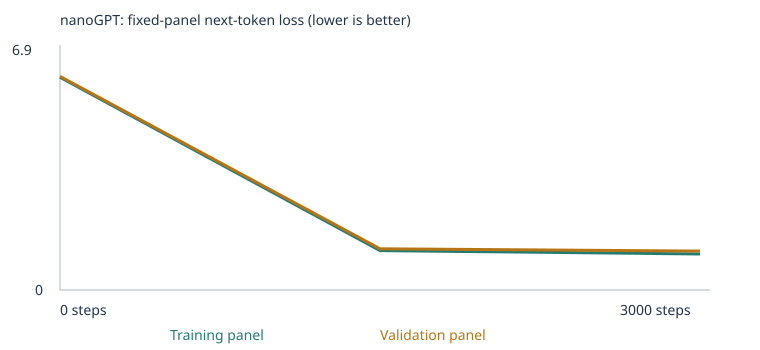

llm_runs/20260923T003334_247389Z.zip

Saved: llm_runs/20260923T003334_247389Z 
Results ZIP: llm_runs/20260923T003334_247389Z.zip


In [11]:
config = {"model":"nanoGPT", "upstream_commit":UPSTREAM_COMMIT, "tokenizer":"word", "corpus_source":corpus_source,
    "corpus_sha256":hashlib.sha256(raw_text.encode()).hexdigest(), "training_steps":TRAINING_STEPS,
    "learning_rate":LEARNING_RATE, "seed":SEED, "n_embd":N_EMBD, "n_head":N_HEAD, "n_layer":N_LAYER,
    "block_size":BLOCK_SIZE, "batch_size":BATCH_SIZE, "vocabulary_size":len(vocabulary),
    "parameters":sum(p.numel() for p in model.parameters()), "train_documents":len(train_docs),
    "validation_documents":len(val_docs), "validation_unknown_rate":unknown_rate, "training_unknown_rate":training_unknown_rate,
    "corpus_files":len(corpus_manifest["files"]), "corpus_mode":CORPUS,
    "evaluation_panel_size":{"train":len(eval_train),"validation":len(eval_val)},
    "evaluation_reduction":"mean over non-padding next-token panel targets",
    "language_eval_suite_sha256":final_language_summary["suite_sha256"],
    "reserved_eval_passages":eval_separation["excluded_passages"],
    "python":sys.version,"torch":str(torch.__version__),"device":DEVICE,"hardware":platform.platform()}
save_json("config.json",config)
save_json("training_summary.json",{"completed_steps":completed_steps,"elapsed_seconds":elapsed,"interrupted":interrupted})
save_json("checkpoint.json",{"format":"classroom-nanogpt-embeddings-v1","config":config,"vocabulary":vocabulary,
    "completed_steps":completed_steps,"weights":{"wte":model.transformer.wte.weight.detach().cpu().tolist()},
    "initial_embeddings":initial_embeddings.tolist(),"token_counts":[counts.get(t,0) for t in vocabulary]})
torch.save({"model":{k:v.detach().cpu() for k,v in model.state_dict().items()},"model_args":vars(model_config),
    "vocabulary":vocabulary,"completed_steps":completed_steps},run_dir/"model.pt")
with (run_dir/"training.csv").open("w",newline="") as file:
    writer = csv.DictWriter(file,fieldnames=["step","training_loss","validation_loss"])
    writer.writeheader()
    writer.writerows(history)
upper = max(row[key] for row in history for key in ["training_loss","validation_loss"])*1.1
def points(key):
    return " ".join(f"{60+row['step']/max(1,completed_steps)*640:.1f},{290-row[key]/upper*235:.1f}" for row in history)
svg = f'''<svg xmlns="http://www.w3.org/2000/svg" width="760" height="350" viewBox="0 0 760 350">
<rect width="760" height="350" fill="white"/><g font-family="sans-serif" font-size="14" fill="#22344a">
<text x="60" y="25">nanoGPT: fixed-panel next-token loss (lower is better)</text>
<path d="M60 45V290H710" fill="none" stroke="#aab8c6"/><text x="35" y="295">0</text>
<text x="12" y="55">{upper:.1f}</text><text x="60" y="315">0 steps</text><text x="620" y="315">{completed_steps} steps</text>
<polyline points="{points('training_loss')}" fill="none" stroke="#247b72" stroke-width="3"/>
<polyline points="{points('validation_loss')}" fill="none" stroke="#b77515" stroke-width="3"/>
<text x="170" y="340" fill="#247b72">Training panel</text><text x="380" y="340" fill="#b77515">Validation panel</text></g></svg>'''
(run_dir/"training_curves.svg").write_text(svg)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
try:
    from IPython.display import SVG, FileLink, display
    display(SVG(svg))
    display(FileLink(archive))
except ImportError:
    pass
print("Saved:",run_dir,"\nResults ZIP:",archive)

## 10. Chat with your trained model
Edit CHAT_PROMPT and rerun the next cell for each new message. Each message starts
fresh; this model continues text and is not instruction-trained. The cell uses the
model you just trained, saves every interaction, and refreshes the results ZIP.
A terminal alternative is: python chat.py --model path/to/model.pt
Include at least three real interactions and a screenshot or short recording.

In [12]:
CHAT_PROMPT = "the customer"
chat_file = run_dir/"chat_transcript.json"
chat_record = json.loads(chat_file.read_text()) if chat_file.exists() else {
    "model_sha256":model_hash(model), "completed_steps":completed_steps,
    "fresh_context_per_prompt":True, "temperature":0.8, "max_tokens":24, "turns":[]}
if chat_record["model_sha256"] != model_hash(model):
    raise ValueError("The model changed. Start a new run instead of mixing chat evidence.")
chat_seed = 2026 + len(chat_record["turns"])
reply = generate_reply(model, vocabulary, CHAT_PROMPT, seed=chat_seed)
print("You:", CHAT_PROMPT, "\nModel:", reply["response"] or "[empty response]")
if reply["unknown_prompt_words"]:
    print("Unknown words:", reply["unknown_prompt_words"])
if reply["prompt_truncated"]:
    print("Long prompt: only the most recent 48 tokens were used.")
chat_record["turns"].append({"prompt":CHAT_PROMPT, "seed":chat_seed, **reply})
save_json("chat_transcript.json",chat_record)
archive = shutil.make_archive(str(run_dir),"zip",run_dir)
print("Saved chat and refreshed ZIP:", archive)
try:
    display(FileLink(archive))
except NameError:
    pass

You: the customer 
Model: hen at the market .


Saved chat and refreshed ZIP: llm_runs/20260923T003334_247389Z.zip


llm_runs/20260923T003334_247389Z.zip

## 11. Explain in your own words
1. What can your corpus teach? What does this particular held-out split test?
2. Trace one word through token, ID and 64-number embedding.
3. Connect a prediction, loss, gradient and the saved parameter update.
4. Which neighbors changed? Why is 3D proximity imperfect?
5. What changed in samples and validation loss? What remains unconvincing?
6. Explain attention, temperature and one next experiment. More training is not
   automatically better; a synthetic corpus does not demonstrate general knowledge.
7. Which eval skills improved? Which lacked vocabulary or examples? Compare the
   starter run with your corpus-extension run using the same 48 tests.
8. Show actual chat interactions and explain one failure or limitation.
Save the executed notebook, evidence and README in your own public repository.
Submit its URL through the course portal. Keep both experiment results.

### Submission check
- Four complete 48-case result sets: starter untrained/trained and expanded untrained/trained.
- A four-row README comparison, category scores, coverage, and linked per-case outputs.
- At least two extension categories, new teaching data, and corpus-separation evidence.
- Actual free continuations, a concrete failure/limitation, and an explanation of the outcomes.
- Both executed notebooks, model evidence, launch instructions, and at least three real chat interactions.
Apply the 4/3/3 grading guidance near the top. No accuracy threshold or guaranteed improvement is required.